In [253]:
import sys 
import os

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from fairchem.core.datasets import AseDBDataset

In [254]:
parent_dir = os.path.abspath(os.path.join('..'))
sys.path.append(parent_dir)

In [255]:
from read_multi_ase import *

In [256]:
def get_molecules_by_type(dataset, mol_type=['biomolecules', 'metal_complexes']):
    n = len(dataset)
    atoms = np.array([dataset.get_atoms(i) for i in range(n)], dtype=object)

    if mol_type is None:
        return atoms.reshape(-1, 1)

    mask = np.fromiter((atom.info.get('data_id') not in mol_type for atom in atoms),\
        dtype=bool, count=n)
    return atoms[mask].reshape(-1, 1)

In [257]:
def process_file(file: Union[str, list[str]], 
                molecule_type: str = 'biomolecules', 
                max_molecules: int = 1000):
    
    """
    Reads one or more .aselmdb files and returns filtered molecules.
    """

    # read in dataset from file names 
    dataset = read_aselmdb(file) 

    # total num of mols in entire dataset 
    n_total = len(dataset) 

    # define array and pre-allocate 
    alloc_size = max_molecules if max_molecules is not None else n_total 
    result = np.zeros((alloc_size, 1), dtype=object)

    count = 0 # for tracking 

    for i in range(n_total):

        if count >= alloc_size:
            break

        atoms = dataset.get_atoms(i) 

        if molecule_type is None or atoms.info.get('data_id') in molecule_type:
            result[count, 0] = atoms
            count += 1

    # cut any unfilled rows if fewer matches than alloc_size
    return result[:count]

In [259]:
files_list = find_files('../../data')
# print(len(files_list))

max_molcules = 10000

# full_dataset = process_file(files_list, molecule_type=None, max_molecules=max_molcules)
# subset = full_dataset[:500] # first 500 entries 

domains = process_file(files_list, molecule_type = ['biomolecules', 'metal_complexes', 'elytes'], max_molecules=max_molcules)

# print(type(full_dataset), type(domains))

In [260]:
# confirm size of dataset 
# print(len(full_dataset))
# print(len(subset))
print(len(domains))

10000


In [ ]:
def get_mol_types(dataset): 
    # initialize  
    n = len(dataset)
    atom_types = np.empty(n, dtype=object)
    
    for idx in range(n): 
        atom_types[idx] = dataset[idx, 0].info['data_id']
    
    labels, counts = np.unique(atom_types, return_counts=True)
    
    return labels, counts

In [ ]:
labels, counts = get_mol_types(domains)

In [ ]:
labels

array(['biomolecules', 'elytes', 'metal_complexes'], dtype=object)

In [ ]:
counts

array([362, 296, 342])

In [ ]:
def get_mol_sizes(dataset): 
    # initialize  
    n = len(dataset)
    atom_counts = np.empty(n, dtype=object)
    
    for idx in range(n): 
        atom_counts[idx] = dataset[idx, 0].info['num_atoms']
    
    return atom_counts

In [ ]:
atom_counts = get_mol_sizes(domains)

In [273]:
def visualize_distributions(dataset): 

    num_molecules = len(dataset)

    labels, counts = get_mol_types(dataset)
    atom_counts = get_mol_sizes(dataset)
    # print(len(labels), len(atom_counts))

    mol_types = np.repeat(labels, counts)
    
    # bar plot for mol types 
    plt.bar(labels, counts)
    plt.xlabel('molecule domain')
    plt.xticks(rotation=90)
    plt.ylabel('counts')
    # plt.text(labels, counts)
    plt.title(f'Molecule type distribution for {num_molecules} molecules')
    plt.tight_layout()
    plt.show()

    # plot size distribution for all molecule types 
    sns.kdeplot(x=atom_counts, label='all', lw=2)
    # plt.xlabel('number of atoms')
    # plt.ylabel('density')
    # plt.title(f'KDE for {num_molecules} molecules (all types)')
    # plt.show()
    
    # plot size distribution for all molecule types 
    for label in labels:
        # get index where true 
        idx = (mol_types == label)
        sns.kdeplot(x=atom_counts[idx], label=label, alpha=0.4)

    plt.xlabel('number of atoms')
    plt.ylabel('density')
    plt.title(f'KDE for {num_molecules} molecules (by types)')
    plt.legend()
    plt.show()

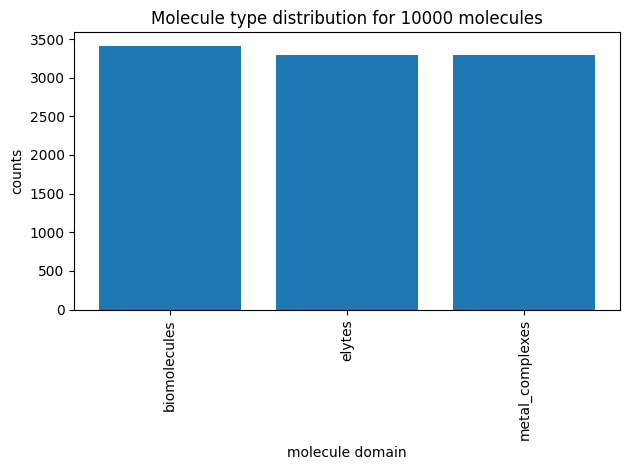

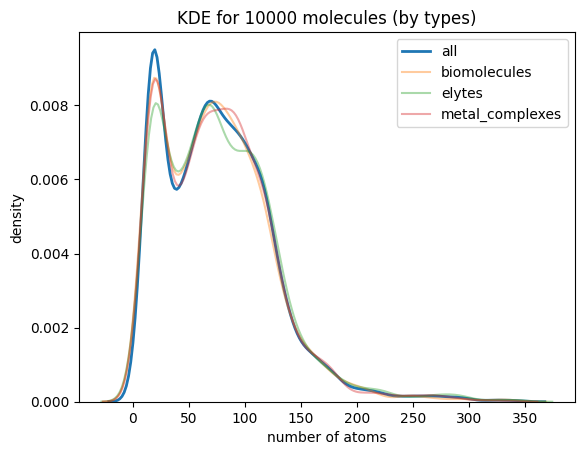

In [274]:
visualize_distributions(domains)